# Pypsa-Eur Analyse und Plotting Tutorial - EVT

## Wichtig: richtiges Environment auswählen
Damit Jupyter Notebooks im richtigen Environment ausgeführt werden, muss das Environment rechts oben im Drop-Down Menü ausgewählt werden:

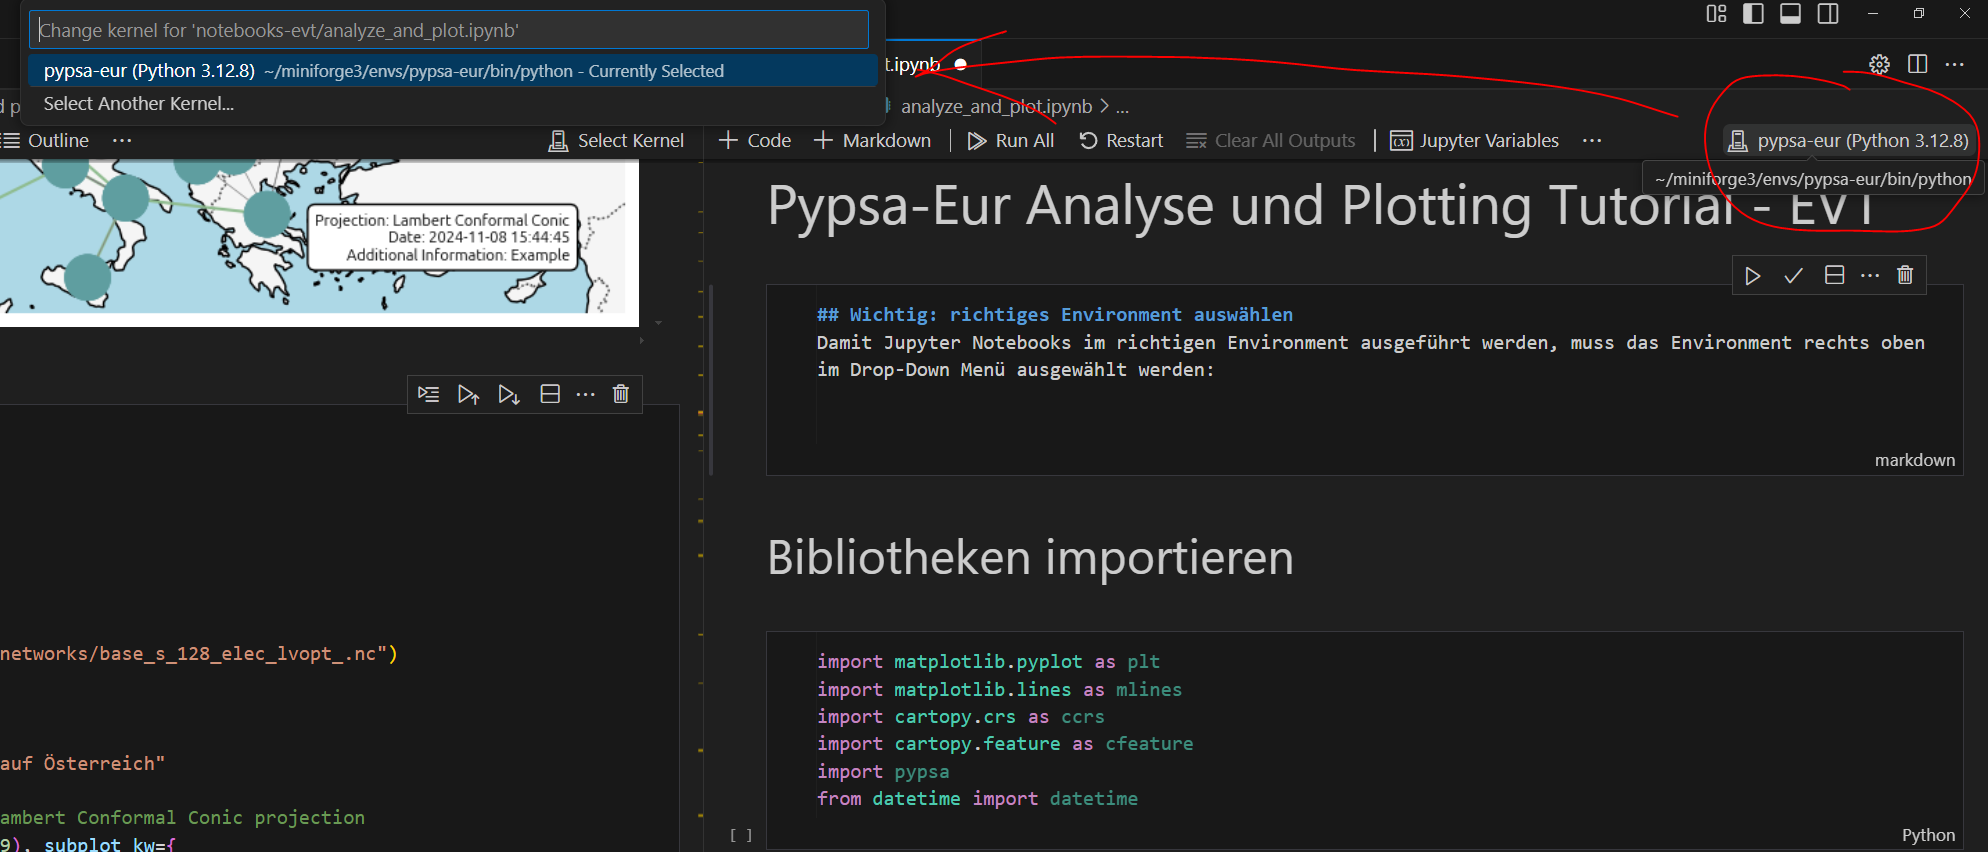

## Allgemein zu Jupyter Notebooks
- Code wird direkt in der Zelle ausgeführt. Damit das funktioniert, muss der Zelltyp Code ausgewählt werden. Textzellen können über Markdown erstellt werden.
- Der Code kann durch klick auf das Play Symbol ausgeführt werden oder per "Strg + Enter" Tastaturkürzel. "Umschalttaste + Enter" führt auch den Code aus, und springt dann zur nächsten Zelle. Sollte keine Zelle existiren, wird eine neue Zelle hinzugefügt.
- Ausgabe des Befehls wird unterhalb der Zelle angezeigt.

## Bibliotheken importieren
Folgende Bibliotheken werden für dieses Tutorial benötigt.

In [2]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pypsa
from datetime import datetime

## PyPSA Netzwerk laden
Bei den Dateipfaden geht ein Jupyter Notebook immmer vom Verzeichnis aus, in dem das Notebook liegt. Daher müssen wir im folgenden Beispiel mit "../.." ins darüber gelegene Verzeichnis (Hauptverzeichnis des Repositorys) wechseln.

In [5]:
# Load the network
n = pypsa.Network("../results/128_wAT_entsoe/networks/base_s_128_elec_lvopt_.nc")

INFO:pypsa.io:Imported network base_s_128_elec_lvopt_.nc has buses, carriers, generators, lines, links, loads, storage_units, stores


## Einfachen Plot ausführen

/home/bjoern/miniforge3/envs/pypsa-eur/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


(<matplotlib.collections.PatchCollection at 0x7fc3f1042510>,
 <matplotlib.collections.LineCollection at 0x7fc3f335bef0>)

/home/bjoern/miniforge3/envs/pypsa-eur/lib/python3.12/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/bjoern/miniforge3/envs/pypsa-eur/lib/python3.12/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


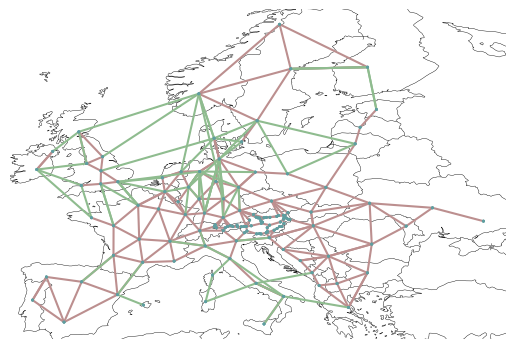

In [6]:
n.plot()

## Erweitertes Plotting
Im Folgenden werden weitere Möglichkeiten zur Formatierung erörtert. Dabei werden auf weitere Python-Bibliotheken zugegriffen.

### Lambertprojektion, Titel und Legenden
Mit folgendem Code wurden weitere Details hinzugefügt und die Kartendarstellung zur bessren Leserlichkeit geändert. Zusätzlich wird eine PDF Datei exportiert, die den Plot beinhaltet.

INFO:pypsa.io:Imported network base_s_128_elec_lvopt_.nc has buses, carriers, generators, lines, links, loads, storage_units, stores
/home/bjoern/miniforge3/envs/pypsa-eur/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


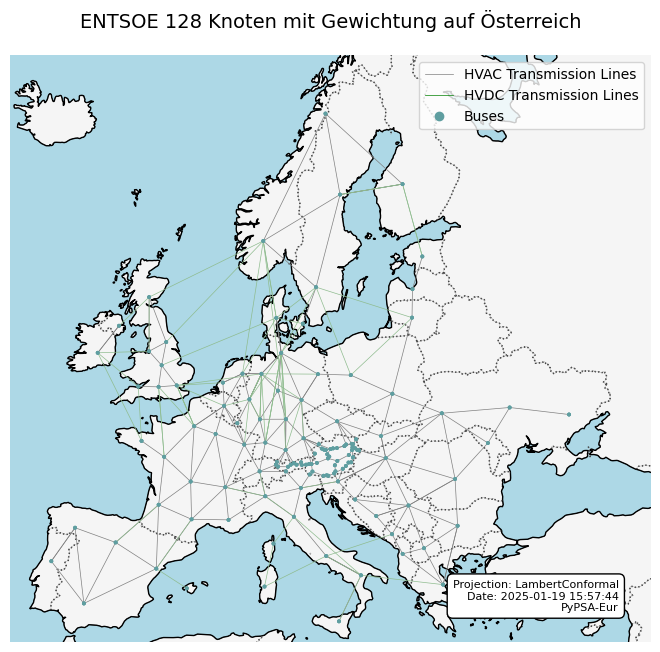

In [11]:
# plotting parameters
network_file = "../results/128_wAT_entsoe/networks/base_s_128_elec_lvopt_.nc"  # Path to network file
projection_type = "LambertConformal"  # Projection type
projection_params = {"central_longitude": 10, "central_latitude": 50}  # Parameters for the projection
title = "ENTSOE 128 Knoten mit Gewichtung auf Österreich"  # Plot title
figsize = (8.27, 11.69)  # Size of the figure (A4)
line_width = 0.5  # Line width for transmission lines
bus_size = 0.02  # Bus size
bus_color = "cadetblue"
line_color = "gray"  # Color for transmission lines (AC)
link_color = "green" # Color for HVDC transmission lines
legend_loc = 'upper right'  # Location of the legend
info_box_position = (0.95, 0.05)  # Position of the information box
font_size_title = 14  # Font size for the title
font_size_info = 8  # Font size for the info box

# Load the network
n = pypsa.Network(network_file)

# Set up the plot with A4 dimensions and configurable projection
fig, ax = plt.subplots(figsize=figsize, subplot_kw={
    "projection": getattr(ccrs, projection_type)(**projection_params)
})

# Add features for the background map
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.OCEAN, color='lightblue')
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)

# Plot the network with transmission lines and buses
n.plot(ax=ax, color_geomap=True, line_widths=line_width, link_widths=line_width, bus_sizes=bus_size, line_colors=line_color, bus_colors=bus_color)

# Create custom legend elements
transmission_legend = mlines.Line2D([], [], color=line_color, linewidth=line_width, label="HVAC Transmission Lines")
link_legend = mlines.Line2D([], [], color=link_color, linewidth=line_width, label="HVDC Transmission Lines")
bus_legend = mlines.Line2D([], [], color=bus_color, marker='o', linestyle='None', markersize=6, label="Buses")

# Add the legend to the plot
ax.legend(handles=[transmission_legend, link_legend, bus_legend], loc=legend_loc)

# Add the title to the plot
ax.set_title(title, fontsize=font_size_title, loc='center', pad=20)

# Add the extra box with projection description, date, and additional information
date_str = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
info_text = f"Projection: {projection_type}\nDate: {date_str}\nPyPSA-Eur"

# Position the text box in the bottom-right corner
ax.text(info_box_position[0], info_box_position[1], info_text, transform=ax.transAxes, fontsize=font_size_info,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))

# Save the plot as a full A4-sized PDF
plt.savefig('network_plot_a4_lambert.pdf', format='pdf', bbox_inches='tight')

# Optionally, display the plot
plt.show()

### Zuschneiden auf Österreich
Um einen Ausschnitt größer darzustellen, kann folgender Code verwendet werden.

INFO:pypsa.io:Imported network base_s_128_elec_lvopt_.nc has buses, carriers, generators, lines, links, loads, storage_units, stores
/home/bjoern/miniforge3/envs/pypsa-eur/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/bjoern/miniforge3/envs/pypsa-eur/lib/python3.12/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/bjoern/miniforge3/envs/pypsa-eur/lib/python3.12/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/bjoern/miniforge3/envs/pypsa-eur/lib/python3.12/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloadin

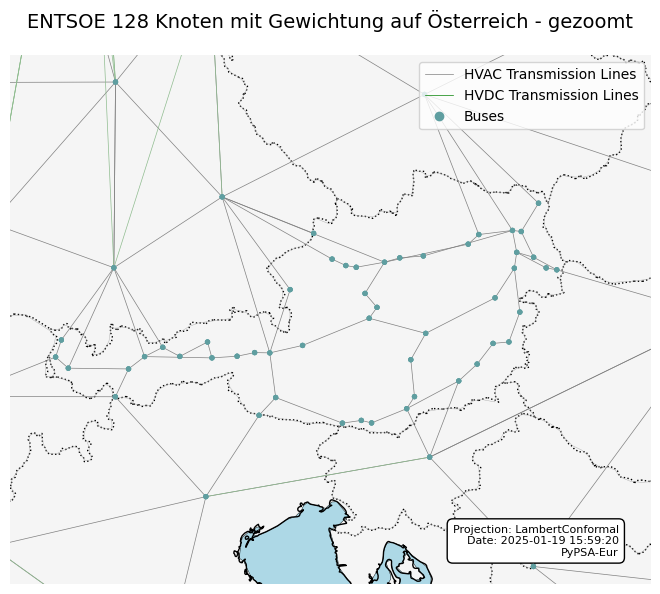

In [12]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pypsa
from datetime import datetime

# plotting parameters
network_file = "../results/128_wAT_entsoe/networks/base_s_128_elec_lvopt_.nc"  # Path to network file
projection_type = "LambertConformal"  # Projection type
projection_params = {"central_longitude": 10, "central_latitude": 50}  # Parameters for the projection
title = "ENTSOE 128 Knoten mit Gewichtung auf Österreich - gezoomt"  # Plot title
figsize = (8.27, 11.69)  # Size of the figure (A4)
line_width = 0.5  # Line width for transmission lines
bus_size = 0.001  # Bus size
bus_color = "cadetblue"
line_color = "gray"  # Color for transmission lines (AC)
link_color = "green" # Color for HVDC transmission lines
legend_loc = 'upper right'  # Location of the legend
info_box_position = (0.95, 0.05)  # Position of the information box
font_size_title = 14  # Font size for the title
font_size_info = 8  # Font size for the info box

# Define a narrower extent around the central point for a closer zoom
extent_lon_range = 4  # Smaller longitude range for more zoom
extent_lat_range = 3  # Smaller latitude range for more zoom
extent = [
    projection_params["central_longitude"] - extent_lon_range,
    projection_params["central_longitude"] + extent_lon_range,
    projection_params["central_latitude"] - extent_lat_range,
    projection_params["central_latitude"] + extent_lat_range
]

# Load the network
n = pypsa.Network(network_file)

# Set up the plot with A4 dimensions and configurable projection
fig, ax = plt.subplots(figsize=figsize, subplot_kw={
    "projection": getattr(ccrs, projection_type)(**projection_params)
})

# Set the extent to crop to the center
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add features for the background map
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.OCEAN, color='lightblue')
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)

# Plot the network with transmission lines and buses
n.plot(ax=ax, color_geomap=True, line_widths=line_width, link_widths=line_width, bus_sizes=bus_size, line_colors=line_color, bus_colors=bus_color, boundaries=[9,18,45,50])

# Create custom legend elements
transmission_legend = mlines.Line2D([], [], color=line_color, linewidth=line_width, label="HVAC Transmission Lines")
link_legend = mlines.Line2D([], [], color=link_color, linewidth=line_width, label="HVDC Transmission Lines")
bus_legend = mlines.Line2D([], [], color=bus_color, marker='o', linestyle='None', markersize=6, label="Buses")

# Add the legend to the plot
ax.legend(handles=[transmission_legend, link_legend, bus_legend], loc=legend_loc)

# Add the title to the plot
ax.set_title(title, fontsize=font_size_title, loc='center', pad=20)

# Add the extra box with projection description, date, and additional information
date_str = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
info_text = f"Projection: {projection_type}\nDate: {date_str}\nPyPSA-Eur"

# Position the text box in the bottom-right corner
ax.text(info_box_position[0], info_box_position[1], info_text, transform=ax.transAxes, fontsize=font_size_info,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))

# Save the plot as a full A4-sized PDF
plt.savefig('network_plot_a4_lambert_Centered.pdf', format='pdf', bbox_inches='tight')

# Optionally, display the plot
plt.show()


## Analyse
PyPSA-Netze erlauben eine einfache Analyse, da unter der Haube Pandas Dataframes verwendet werden.

### Identifizieren der Grenzleitungen von Österreich
In diesem Beispiel werden alle Leitungen identifiziert, die Österreich mit einem anderen Land verbinden.

Dazu muss pandas importiert werden.

In [15]:
import pandas as pd

Die Stromleitungen werden gefiltert und als neues Dataframe abgespeichert. Zusätzlich wird das Ergebnis als csv Datei exportiert.

In [17]:
# Assume `network` is your PyPSA network object
country_code = "AT"  # Replace with your specific country code

# Get the buses and lines data
buses = n.buses
lines = n.lines

# Merge lines with bus data for both ends of each line
lines_with_buses = pd.merge(
    lines,
    buses[['country']],
    left_on='bus0', right_index=True,
    suffixes=('', '_bus0')
).merge(
    buses[['country']],
    left_on='bus1', right_index=True,
    suffixes=('', '_bus1')
)

# Filter for cross-border lines involving the target country
cross_border_lines = lines_with_buses[
    (lines_with_buses['country'] == country_code) |
    (lines_with_buses['country_bus1'] == country_code)
]
cross_border_lines = cross_border_lines[cross_border_lines['country'] != cross_border_lines['country_bus1']]

# Export to CSV
cross_border_lines.to_csv(f"{country_code}_cross_border_lines.csv", index=False)

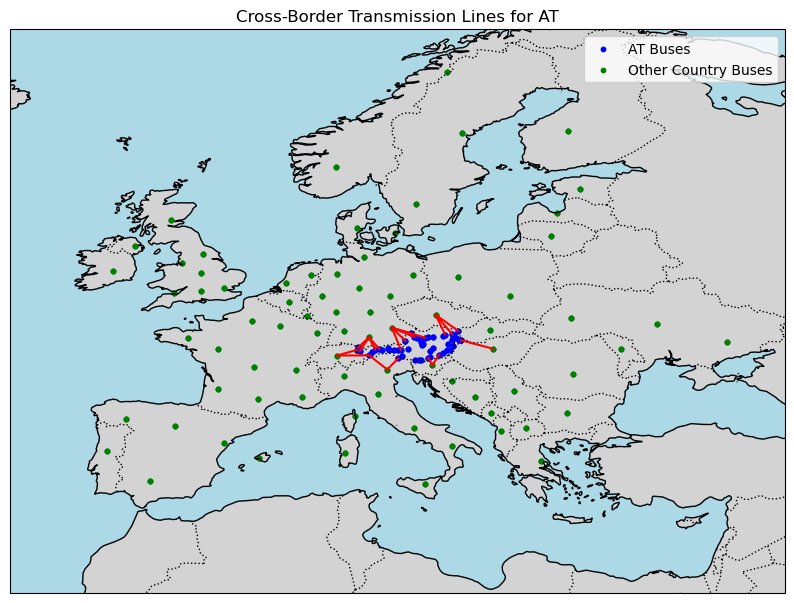

In [20]:
from shapely.geometry import LineString
import geopandas as gpd

network = n
# Define the country code of interest
country_code = "AT"

# Extract node coordinates and country information from buses
buses = network.buses[['x', 'y', 'country']]

# Get cross-border lines connected to the specified country
cross_border_lines = lines_with_buses[
    ((lines_with_buses['country'] == country_code) | (lines_with_buses['country_bus1'] == country_code)) &
    (lines_with_buses['country'] != lines_with_buses['country_bus1'])
]

# Convert lines to GeoDataFrame for plotting
line_geometries = []
for _, line in cross_border_lines.iterrows():
    # Create a line geometry from the coordinates of both ends
    line_geometry = LineString([
        (buses.loc[line['bus0'], 'x'], buses.loc[line['bus0'], 'y']),
        (buses.loc[line['bus1'], 'x'], buses.loc[line['bus1'], 'y'])
    ])
    line_geometries.append(line_geometry)

cross_border_gdf = gpd.GeoDataFrame(cross_border_lines, geometry=line_geometries)

# Set up a Cartopy map
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([-15, 40, 30, 70], crs=ccrs.PlateCarree())  # Adjust the extent as needed

# Add map features for context
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, color="lightgray")
ax.add_feature(cfeature.OCEAN, color="lightblue")

# Plot the cross-border lines
for line in cross_border_gdf.geometry:
    ax.plot(
        [point[0] for point in line.coords],
        [point[1] for point in line.coords],
        color="red",
        linewidth=1.5,
        transform=ccrs.PlateCarree()
    )

# Plot buses
ax.scatter(buses[buses['country'] == country_code]['x'], buses[buses['country'] == country_code]['y'],
           color='blue', s=10, transform=ccrs.PlateCarree(), label=f"{country_code} Buses")
ax.scatter(buses[buses['country'] != country_code]['x'], buses[buses['country'] != country_code]['y'],
           color='green', s=10, transform=ccrs.PlateCarree(), label="Other Country Buses")

# Customize plot
plt.title(f"Cross-Border Transmission Lines for {country_code}")
plt.legend()
plt.show()

Die Ausgabe lässt sich auch wieder zoomen...

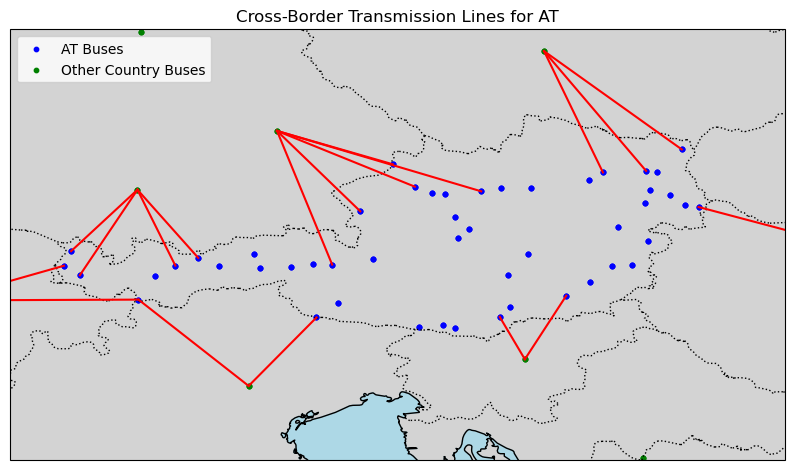

In [21]:
# Define the country code and extent of interest
country_code = "AT"
country_extent = [9,18,45,50]  # Set to the specific lat/lon bounds for Germany (adjust as needed)

# Extract node coordinates and country information from buses
buses = network.buses[['x', 'y', 'country']]

# Get cross-border lines connected to the specified country
cross_border_lines = lines_with_buses[
    ((lines_with_buses['country'] == country_code) | (lines_with_buses['country_bus1'] == country_code)) &
    (lines_with_buses['country'] != lines_with_buses['country_bus1'])
]

# Convert lines to GeoDataFrame for plotting
line_geometries = []
for _, line in cross_border_lines.iterrows():
    line_geometry = LineString([
        (buses.loc[line['bus0'], 'x'], buses.loc[line['bus0'], 'y']),
        (buses.loc[line['bus1'], 'x'], buses.loc[line['bus1'], 'y'])
    ])
    line_geometries.append(line_geometry)

cross_border_gdf = gpd.GeoDataFrame(cross_border_lines, geometry=line_geometries)

# Set up a Cartopy map
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent(country_extent, crs=ccrs.PlateCarree())

# Add map features for context
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, color="lightgray")
ax.add_feature(cfeature.OCEAN, color="lightblue")

# Plot the cross-border lines
for line in cross_border_gdf.geometry:
    ax.plot(
        [point[0] for point in line.coords],
        [point[1] for point in line.coords],
        color="red",
        linewidth=1.5,
        transform=ccrs.PlateCarree()
    )

# Plot buses
ax.scatter(buses[buses['country'] == country_code]['x'], buses[buses['country'] == country_code]['y'],
           color='blue', s=10, transform=ccrs.PlateCarree(), label=f"{country_code} Buses")
ax.scatter(buses[buses['country'] != country_code]['x'], buses[buses['country'] != country_code]['y'],
           color='green', s=10, transform=ccrs.PlateCarree(), label="Other Country Buses")

# Customize plot
plt.title(f"Cross-Border Transmission Lines for {country_code}")
plt.legend()

# Save the plot as a full A4-sized PDF
plt.savefig(f"Cross-Border Transmission Lines for {country_code}.pdf", format='pdf', bbox_inches='tight')

plt.show()